In [1]:
import numpy as np
import pandas as pd
import pickle

import importlib

#### Load Test Data

In [2]:
real_norm = np.load("./TestData/TEST_real_norm.npy")
real_asmi = np.load("./TestData/TEST_real_asmi.npy")
real_imi = np.load("./TestData/TEST_real_imi.npy")

real_norm_label  = "NORM"
real_asmi_label = "ASMI"
real_imi_label = "IMI"

In [3]:
asmi_fnorm = np.load("./TestData/TEST_fake_asmi_from_norm.npy")
asmi_fimi = np.load("./TestData/TEST_fake_asmi_from_imi.npy")

imi_fnorm = np.load("./TestData/TEST_fake_imi_from_norm.npy")
imi_fasmi = np.load("./TestData/TEST_fake_imi_from_asmi.npy")

norm_fasmi = np.load("./TestData/TEST_fake_norm_from_asmi.npy")
norm_fimi = np.load("./TestData/TEST_fake_norm_from_imi.npy")

asmi_fnorm_label = "ASMI_from_NORM"
asmi_fimi_label = "ASMI_from_IMI"

imi_fnorm_label = "IMI_from_NORM"
imi_fasmi_label = "IMI_from_ASMI"

norm_fasmi_label = "NORM_from_ASMI"
norm_fimi_label = "NORM_from_IMI"

print(norm_fasmi.shape, norm_fimi.shape, asmi_fnorm.shape, asmi_fimi.shape, imi_fnorm.shape, imi_fasmi.shape)

(10, 40, 12) (10, 40, 12) (10, 40, 12) (10, 40, 12) (10, 40, 12) (10, 40, 12)


### Test DataClass

In [ ]:
import ECG_Quality_Evaluation.make_data as make_data
importlib.reload(make_data)
from ECG_Quality_Evaluation.make_data import make_data_class

In [5]:
real_labels_list = ["ASMI", "ASMI", "IMI", "IMI", "NORM",  "NORM"]
real_data_list = [real_asmi, real_asmi, real_imi, real_imi, real_norm, real_norm]
gen_labels_list = ["asmi_fimi","asmi_fnorm","imi_fasmi", "imi_fnorm", "norm_fasmi",  "norm_fimi",  ]
gen_data_list = [asmi_fimi, asmi_fnorm, imi_fasmi, imi_fnorm, norm_fasmi, norm_fimi]

ecg_datasets = make_data_class(real_labels_list, real_data_list, gen_labels_list, gen_data_list)

### Test plot paired ECGs

In [6]:
import plot_12L_ecg
importlib.reload(plot_12L_ecg)
from plot_12L_ecg import get_paired_plots

Plotting ASMI to asmi_fimi...


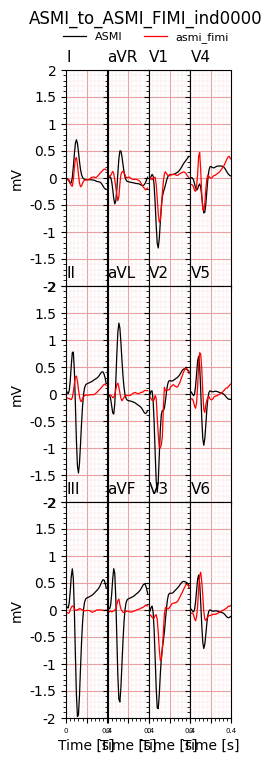

--------------------------------------------------------------------------------------------
Plotting ASMI to asmi_fnorm...


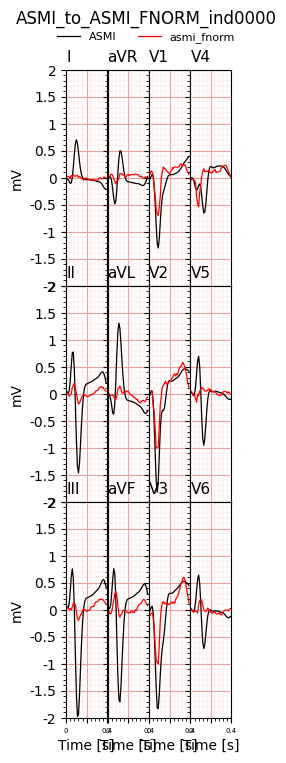

--------------------------------------------------------------------------------------------
Plotting IMI to imi_fasmi...


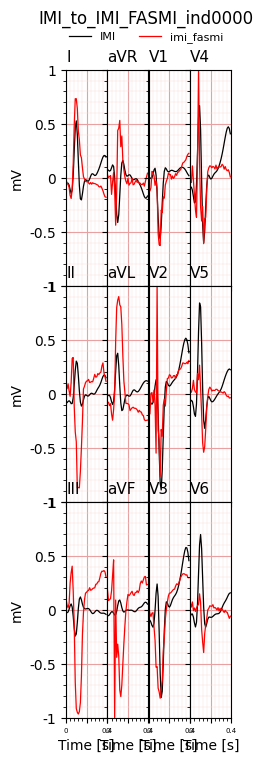

--------------------------------------------------------------------------------------------
Plotting IMI to imi_fnorm...


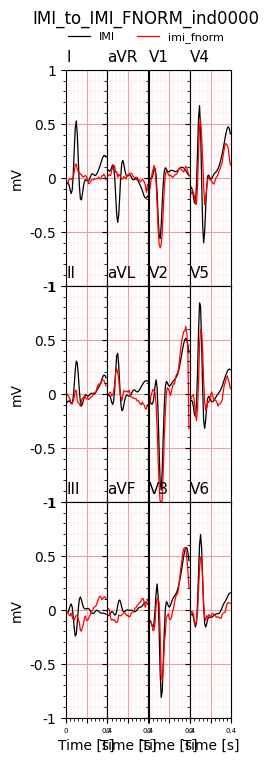

--------------------------------------------------------------------------------------------
Plotting NORM to norm_fasmi...


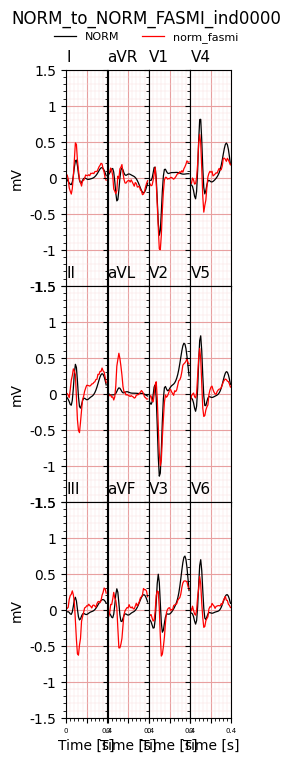

--------------------------------------------------------------------------------------------
Plotting NORM to norm_fimi...


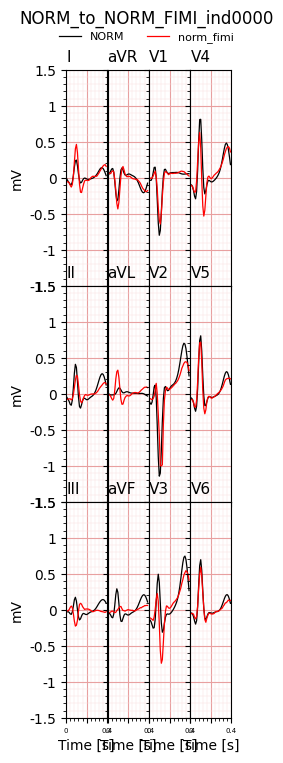

--------------------------------------------------------------------------------------------


In [7]:
index = 0
get_paired_plots(ecg_datasets, real_fake_labels = None,  rand_index=False ,  given_index = index,  seed = 42, 
                     show_plot = True, save_folder = None, sampling_frq = 100)

### TEST Ecg BANDS

In [8]:
import plot_ecg_bands
importlib.reload(plot_ecg_bands)
from plot_ecg_bands import plot_bands_datasets

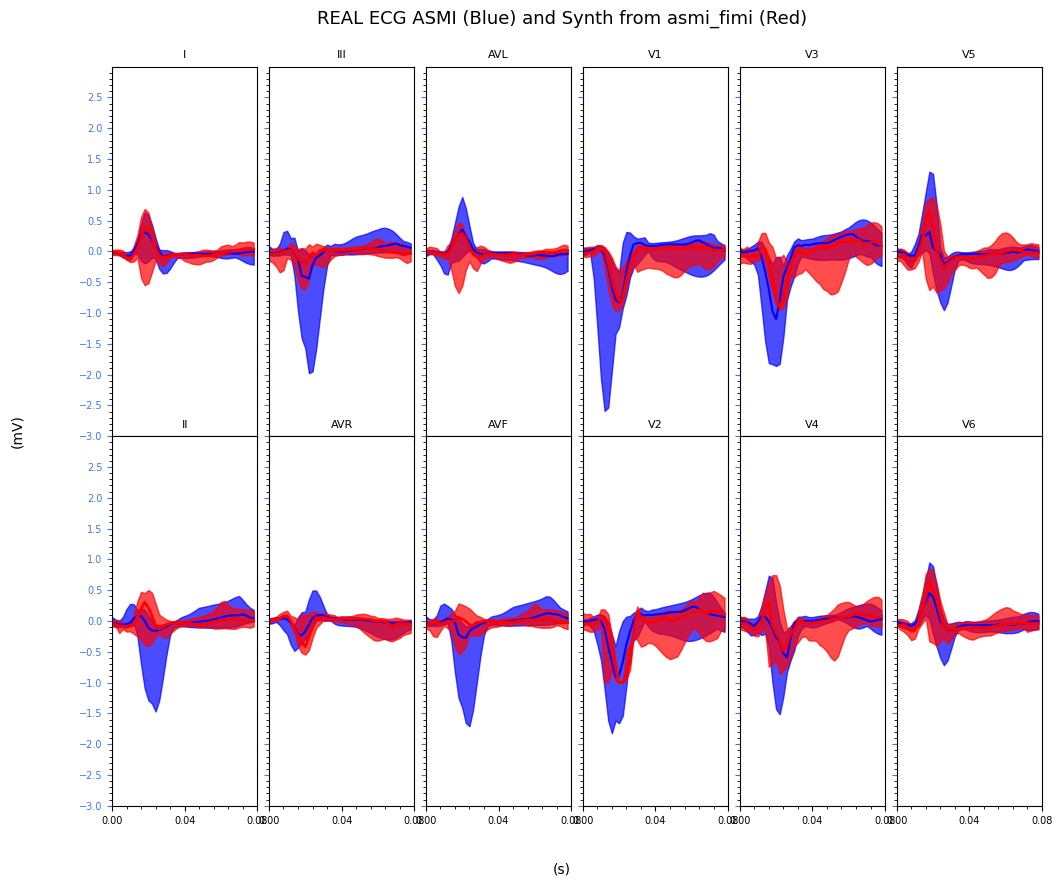

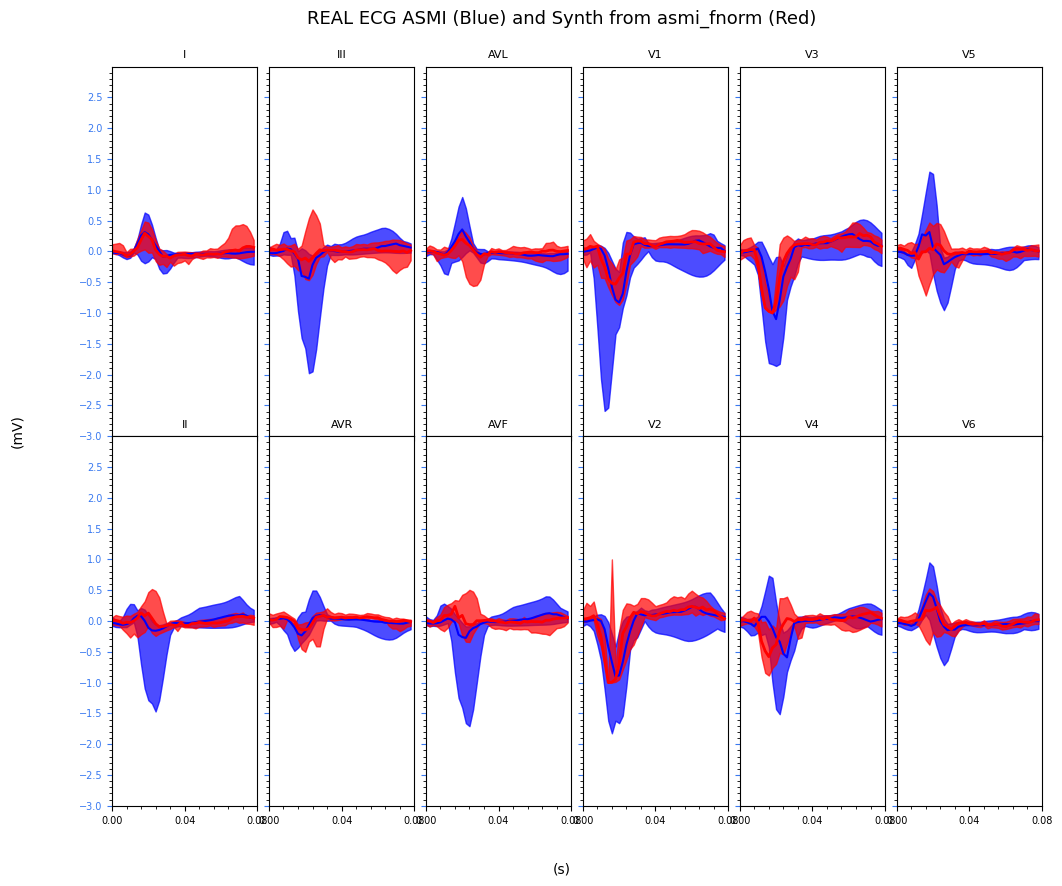

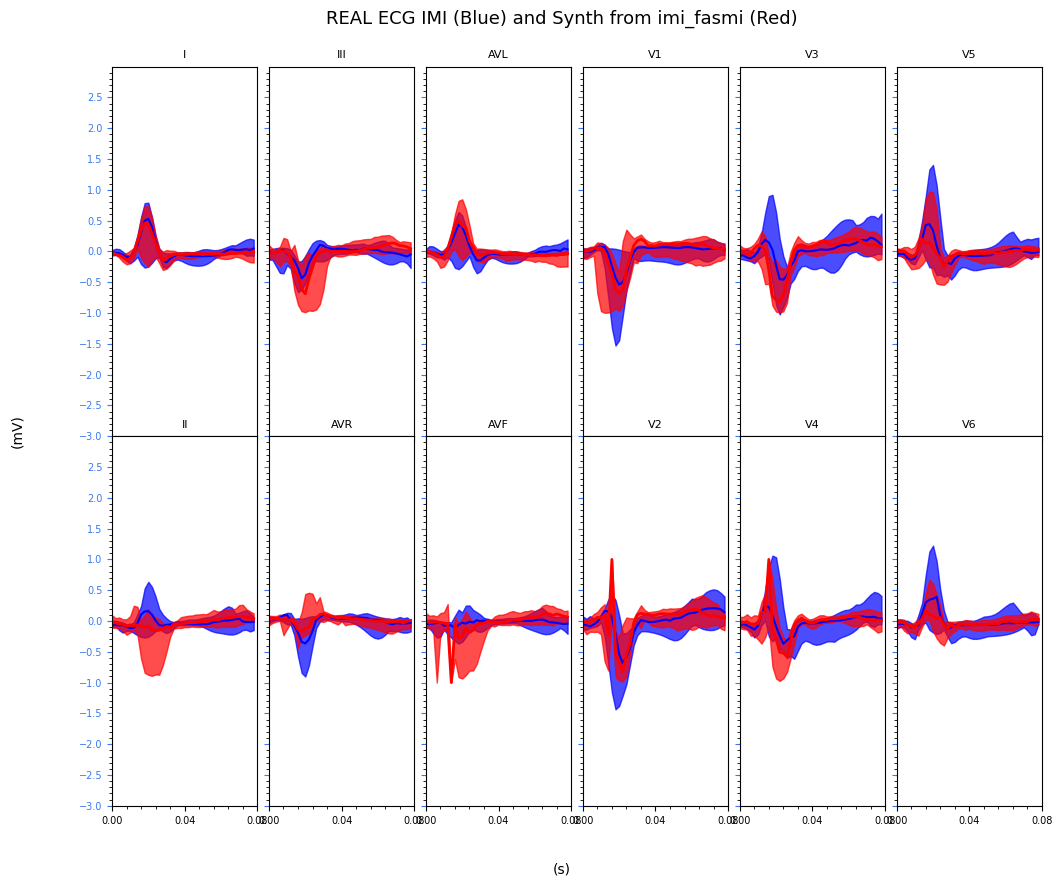

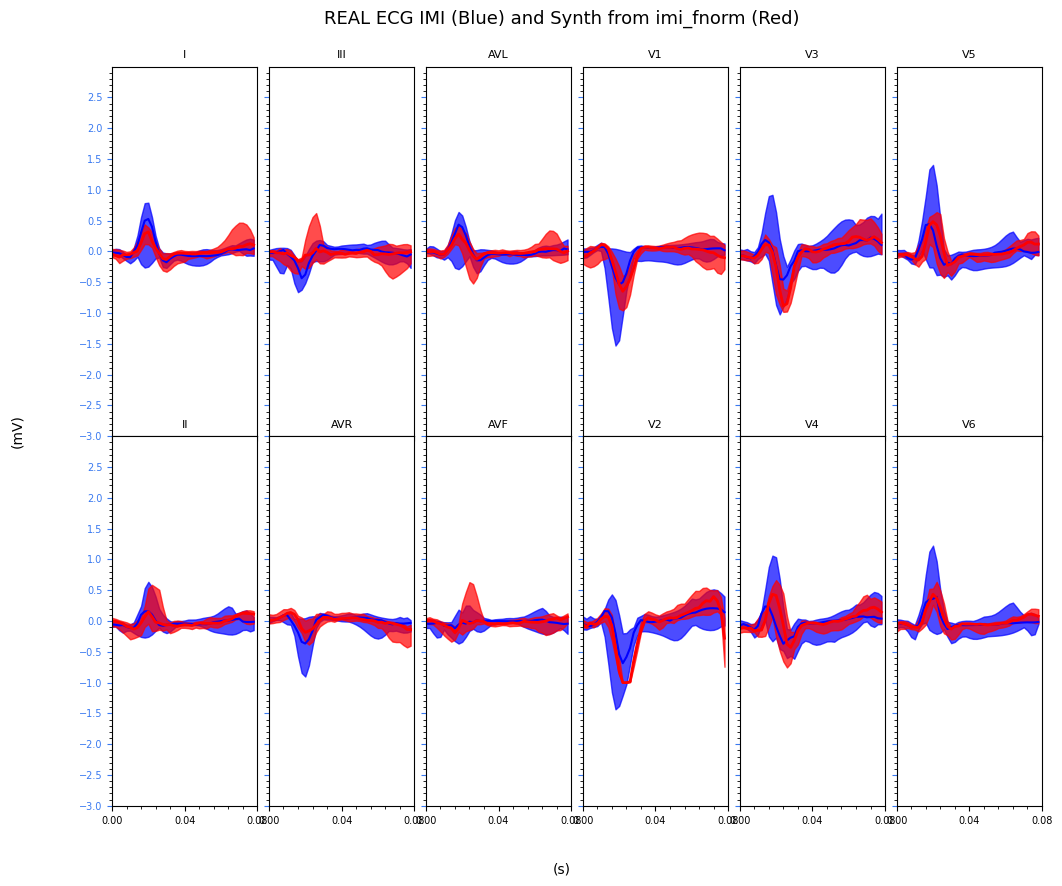

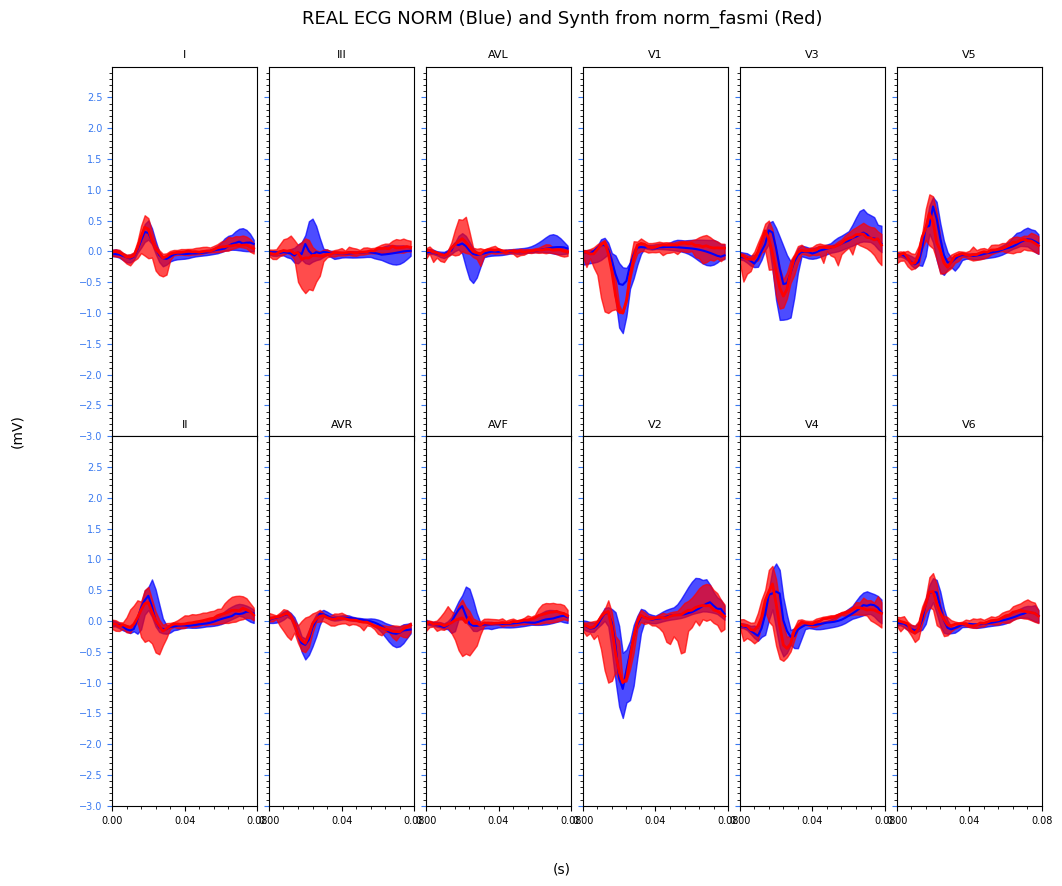

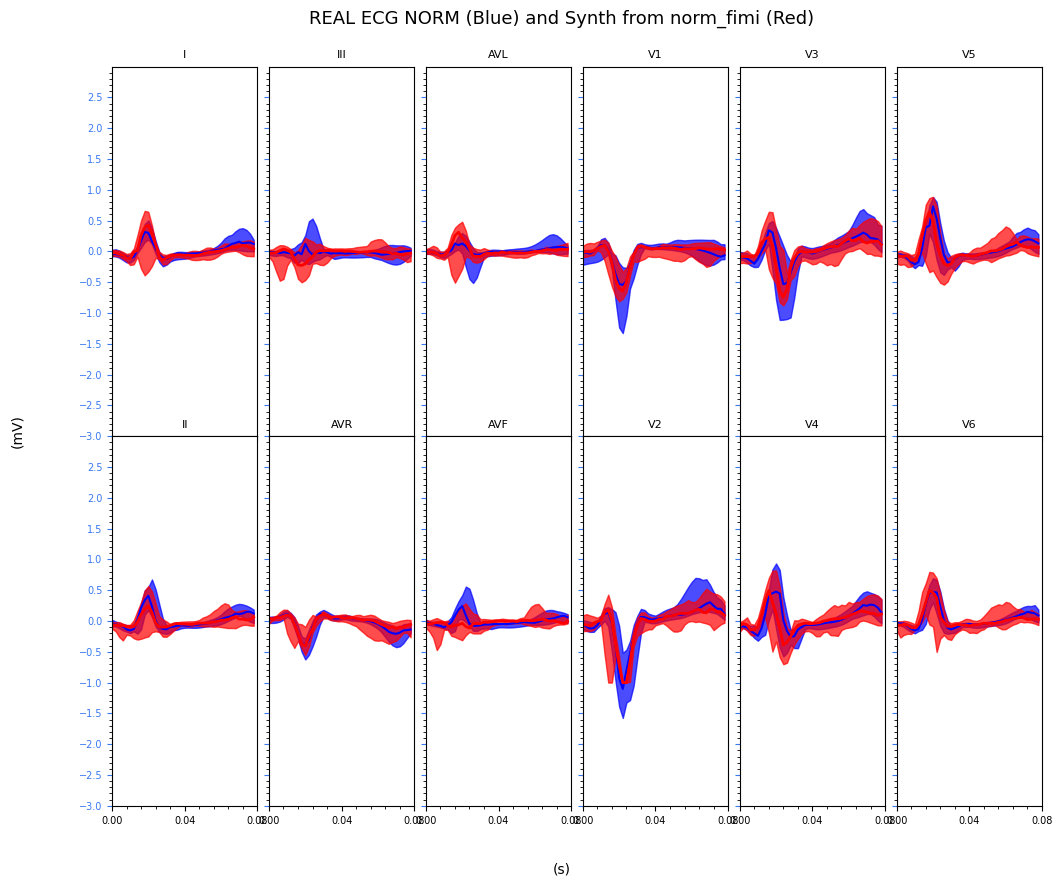

In [9]:
save_bands_folder = None #"/home/ECG_Quality_Evaluation/Test_Figs"
sampling_freq = 500
plot_bands_datasets(ecg_datasets, save_figs_folder = save_bands_folder, 
                    bands = True, ecg_sampling_frequency = sampling_freq, 
                    show_avg_ecg = True, grid_on = False)

### Test UMAP Plots

In [10]:
import plot_umap_maps
importlib.reload(plot_umap_maps)
from plot_umap_maps import plot_UMAP_datasets, make_2d_UMAP_datapairs

  0%|          | 0/6 [00:00<?, ?it/s]/workspace/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/workspace/.venv/lib/python3.10/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
 17%|█▋        | 1/6 [00:05<00:28,  5.65s/it]/workspace/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/workspace/.venv/lib/python3.10/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(
/workspace/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/workspace/.venv/lib/python3.10/site-packages/umap/umap_.py:2462: UserWarning: n

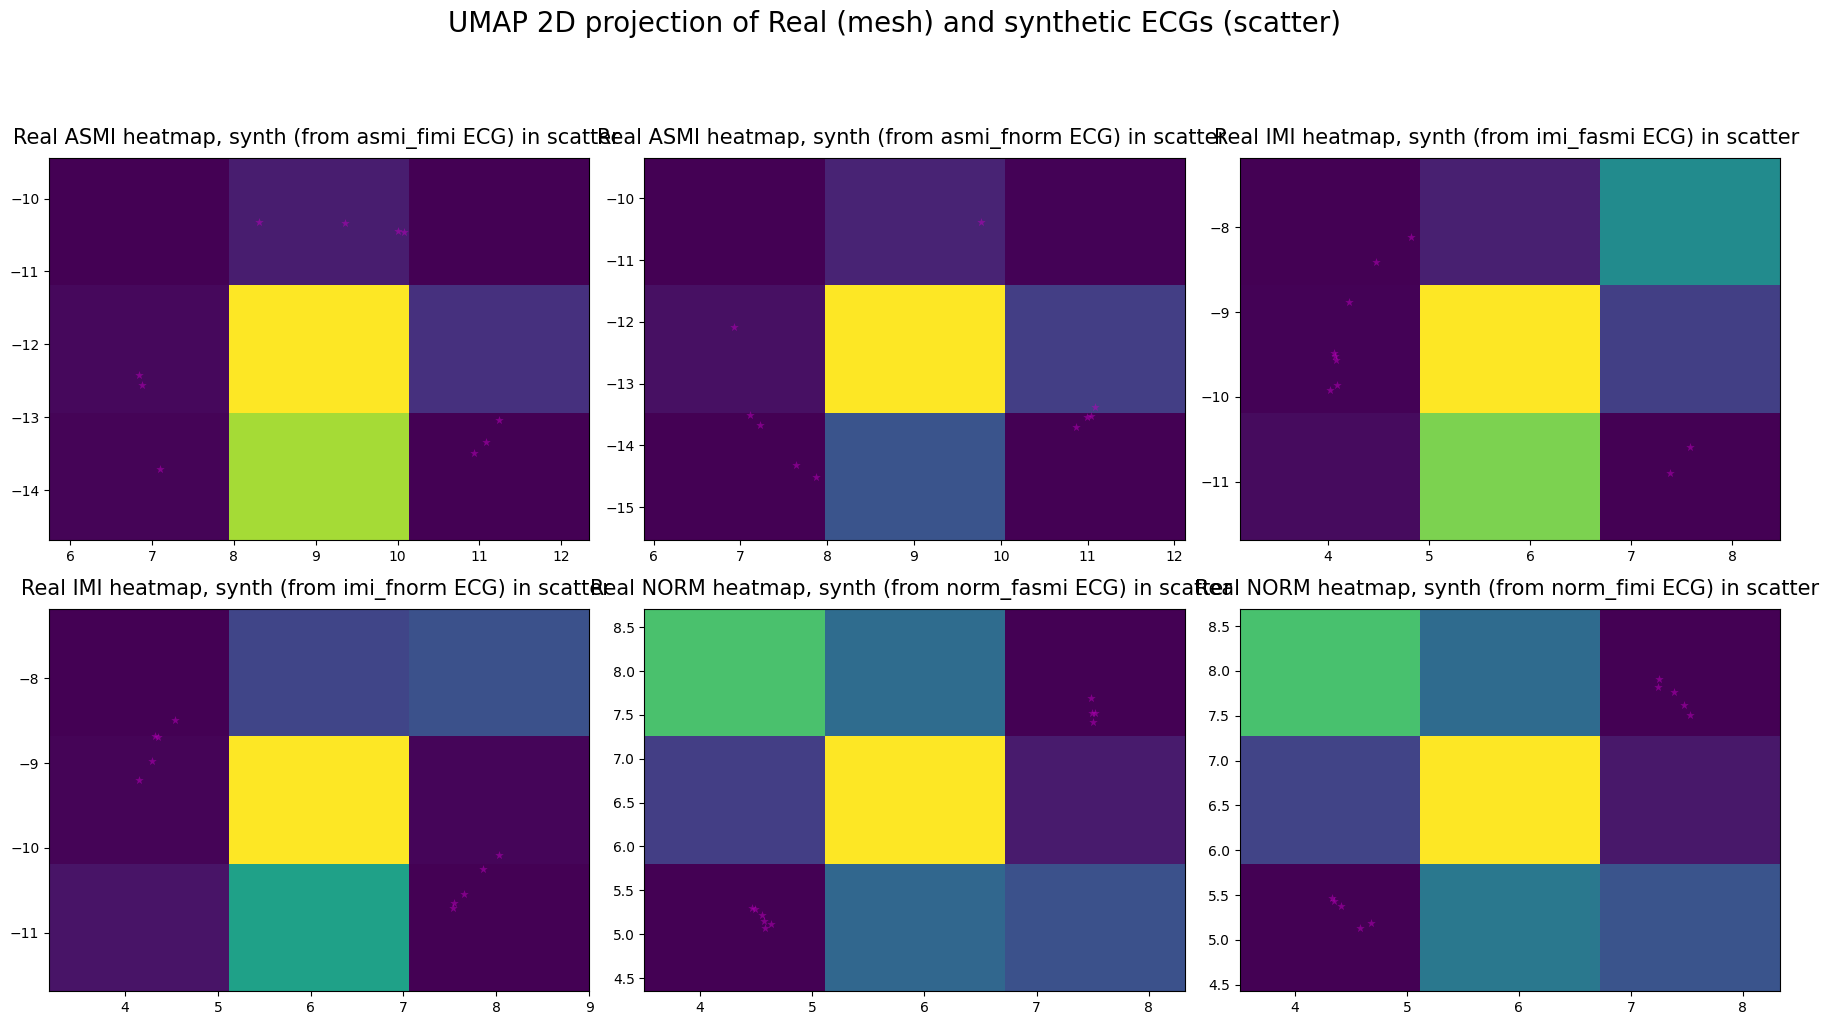

In [11]:
umap_ecg_datapairs = make_2d_UMAP_datapairs(ecg_datasets, random_state = 42)
plot_UMAP_datasets(umap_ecg_datapairs, title_on = True, save_path = None, save_single = None )

## Test GAN-Train-Test scores

In [12]:
import GAN_train_test
importlib.reload(GAN_train_test)
from GAN_train_test import compute_gan_train_test_scores

In [13]:
train_config = {
    "device": "cuda",      # or "cpu"
    "test_size": 0.2,
    "random_state": 42,
    "batch_size": 32,
    "epochs": 15,
    "lr": 1e-3,

    "aux_cls_features": [8,16,32,64],
    "aux_cls_kernels": [5, 5, 3, 3],
    "aux_cls_strides": [1, 2, 2, 1],
    "aux_cls_padding":  [2, 2, 1, 1],
    "n_classes": 3,
}

In [14]:
# Train AUX lcassifier, this can be anything really. As long as it's trainable via CE
import GAN_train_test_classifier
importlib.reload(GAN_train_test_classifier)
from GAN_train_test_classifier import ECG_Classifier

gan_train_model = ECG_Classifier(features=train_config["aux_cls_features"],
                                 kernels=train_config["aux_cls_kernels"],
                                 strides=train_config["aux_cls_strides"],
                                 padding=train_config["aux_cls_padding"],
                                 n_classes=train_config["n_classes"],
                                 name = "GAN-train")

gan_test_model = ECG_Classifier(features=train_config["aux_cls_features"],
                                 kernels=train_config["aux_cls_kernels"],
                                 strides=train_config["aux_cls_strides"],
                                 padding=train_config["aux_cls_padding"],
                                 n_classes=train_config["n_classes"],
                                 name = "GAN-test")


/workspace/.venv/lib/python3.10/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Encoding labels dictionary:  {0: 'ASMI', 1: 'IMI', 2: 'NORM'}
GAN train model training on FAKE DATA...


Train AUX Model: 100%|██████████| 15/15 [00:00<00:00, 167.44epoch/s]




GAN test model training on REAL DATA...


Train AUX Model: 100%|██████████| 15/15 [00:00<00:00, 168.04epoch/s]


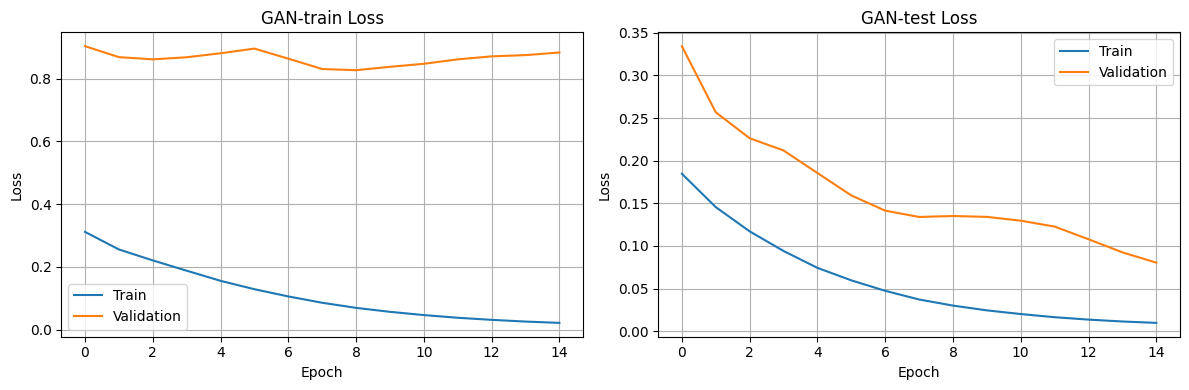

{'GAN-test': {'baseline': 0.5833333333333334, 'score': 0.4166666666666667},
 'GAN-train': {'baseline': 0.4166666666666667, 'score': 0.5833333333333334}}


In [16]:
save_folder = "./Test_Figs"

compute_gan_train_test_scores(gan_train_model, gan_test_model, ecg_datasets, train_config, 
                                  plot_loss_hist = True, save_folder = save_folder)

### Test ST-segment Computation

In [23]:
import ST_segments_evaluation
importlib.reload(ST_segments_evaluation)

from ST_segments_evaluation import plot_multiple_st_radar

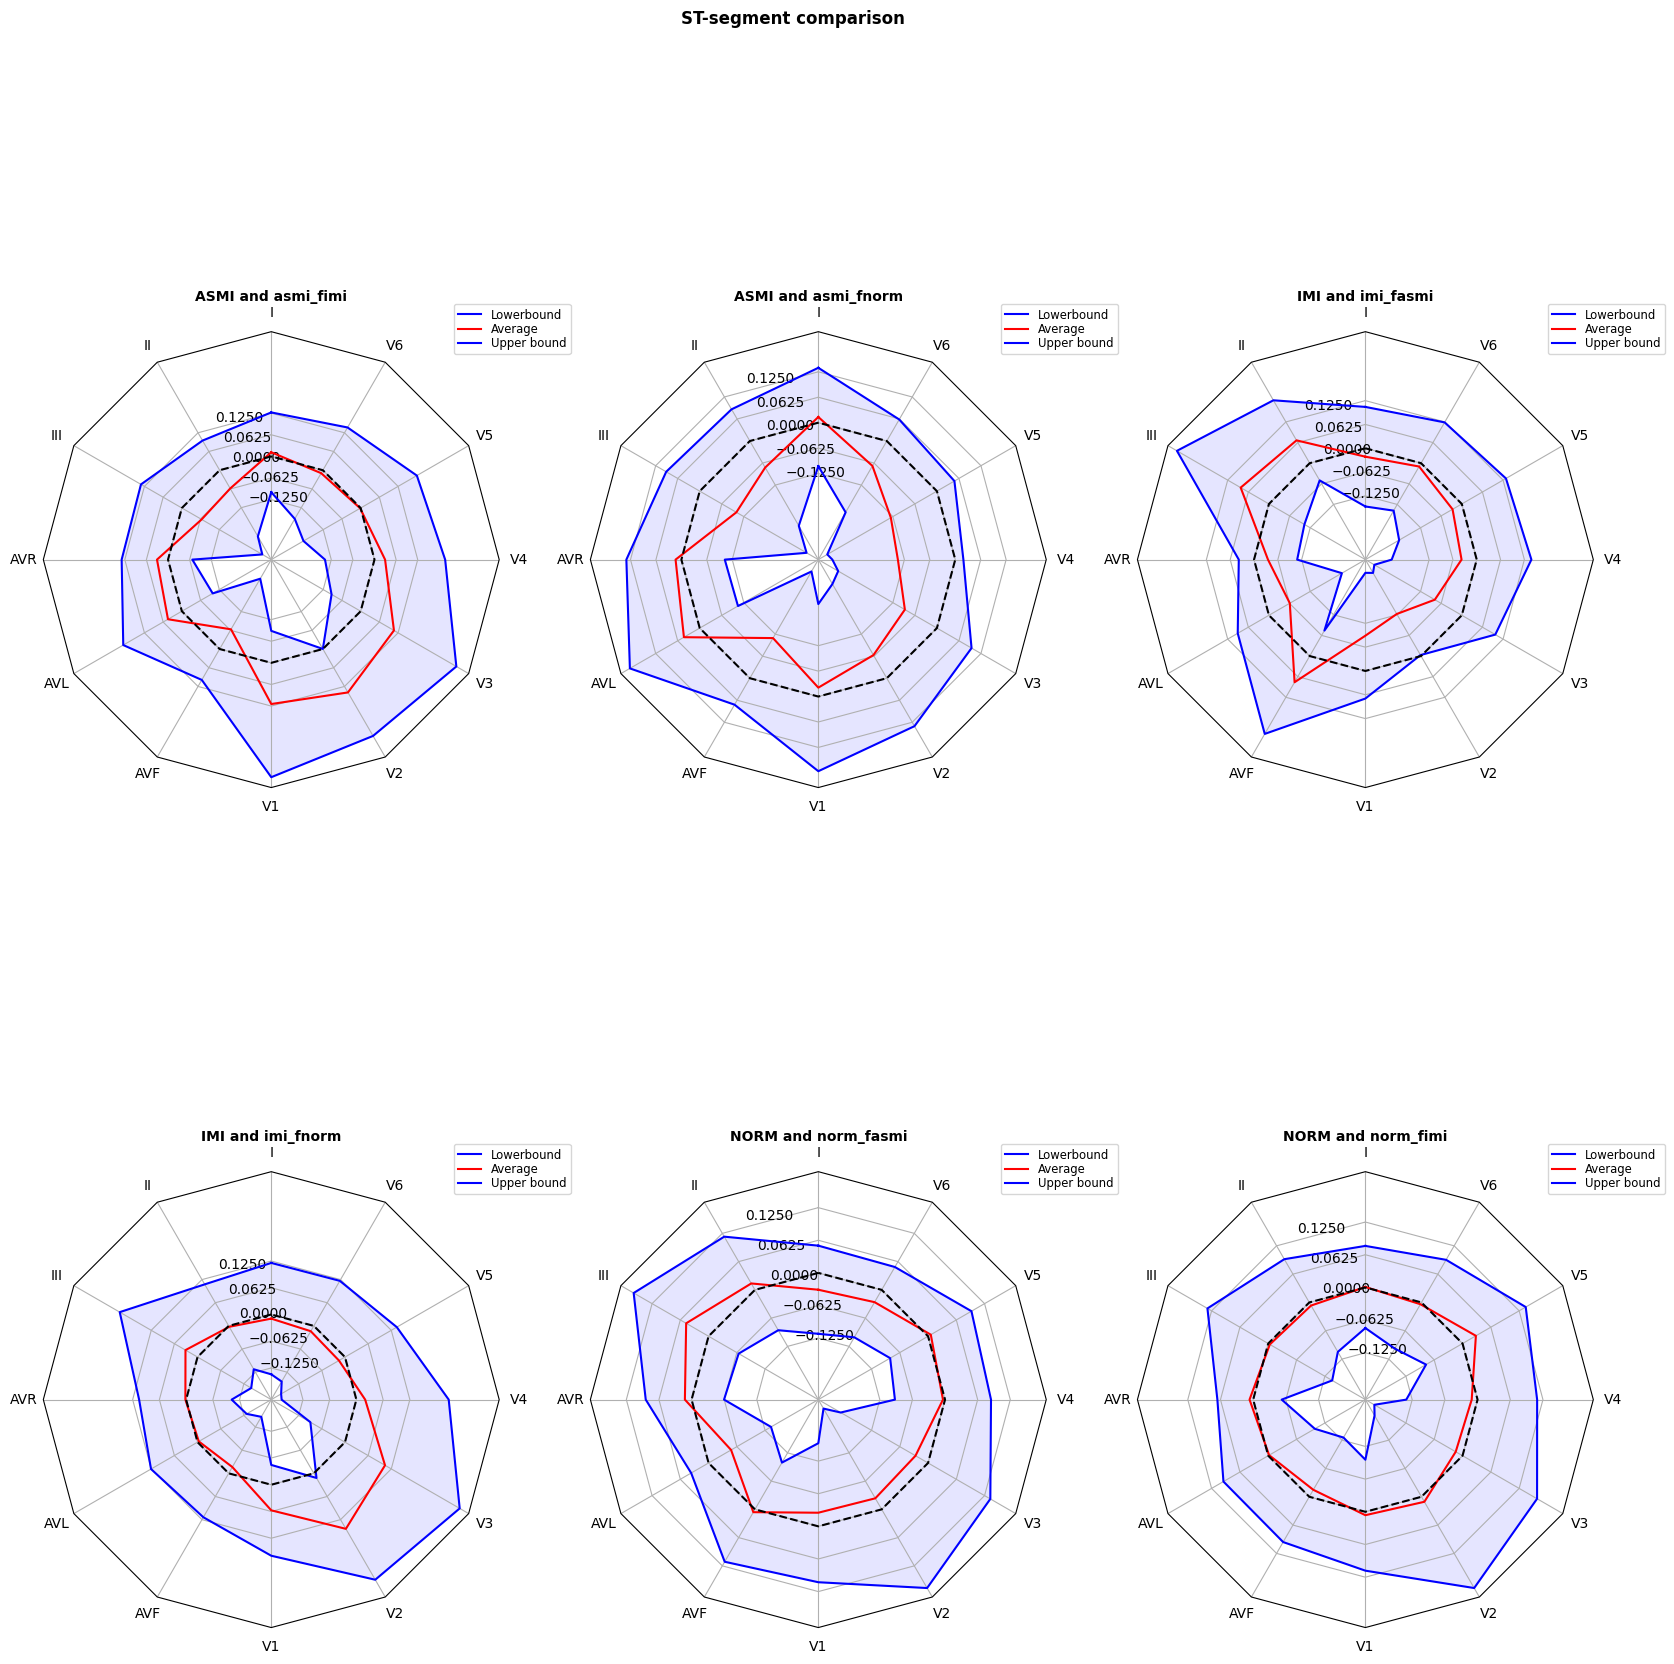

: 

In [ ]:
save_folder = "./Test_Figs"
plot_multiple_st_radar(ecg_datasets, st_start=13, st_end=21, fig_size=(20,20),
                       save_folder=save_folder, show_plot = True )